In [1]:
# useful libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# setting up default plotting parameters
%matplotlib inline

plt.rcParams['figure.figsize'] = [20.0, 7.0]
plt.rcParams.update({'font.size': 22,})

sns.set_palette('viridis')
sns.set_style('white')
sns.set_context('talk', font_scale=0.8)

In [3]:
# read in data
df = pd.read_csv('train.csv')

print(df.shape)
df.head()

(967332, 14)


,auctionId,timeStamp,placementId,websiteId,hashedRefererDeepThree,country,opeartingSystem,browser,browserVersion,device,environmentType,integrationType,articleSafenessCategorization,isSold
0,001ed16b-dd08-4599-b8ef-4f56a373c454_6e5f1087-...,1603815466,120706,68203,1ae7c2d3c28b711c072d8e2eb3869fa59090669bdc153e...,US,Windows,Chrome,86_0,PC,js-web,2,safe,False
1,0024b36a-4fb5-4070-88fb-fc0bfb1909ed,1603974586,69454,42543,df1108bf6ae49dbccf5eab60ff9d04a6a09dda60ec7290...,RO,Android,Facebook App,293_0,Phone,js-fbwv,1,unsafe,False
2,003630fa-ad63-4283-be1b-141670132d70_f37c2b23-...,1604229969,100170,57703,cc6957e8aec85a4d920991c53874c5d0780bbfbd469802...,UK,Android,Facebook App,294_0,Phone,js-web,2,safe,True
3,0048c65a-ce76-43ba-98d2-8e87607468f8,1604156610,100446,57797,7fc0bb7a65d074e003cce786cda2b070f80dd47179c4b9...,ES,Android,Chrome Mobile,86_0,Phone,js-ampsf,1,safe,True
4,0056b8a7-54f9-4ac8-8d50-f725bf377872,1604004493,119517,67613,3a6552ccbf66ad166aa9005c3e08f70716abd676cfd87b...,FR,Android,Facebook App,293_0,Phone,js-fbwv,1,unsafe,False


In [4]:
df.set_index('auctionId', inplace = True, drop = True)

Partie preprocesssing

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 967332 entries, 001ed16b-dd08-4599-b8ef-4f56a373c454_6e5f1087-4b44-440a-87d6-0ff49d964c57 to ffe012ef-b4ac-476a-91b1-a340bad260ee
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype
---  ------                         --------------   -----
 0   timeStamp                      967332 non-null  int64
 1   placementId                    967332 non-null  int64
 2   websiteId                      967332 non-null  int64
 3   hashedRefererDeepThree         951349 non-null  str  
 4   country                        966900 non-null  str  
 5   opeartingSystem                967332 non-null  str  
 6   browser                        967332 non-null  str  
 7   browserVersion                 837388 non-null  str  
 8   device                         967332 non-null  str  
 9   environmentType                967328 non-null  str  
 10  integrationType                967332 non-null  int64
 11  articleSafenessCategorization  

In [13]:
print(df[df['isSold']==1]['isSold'].count())
print(df[df['isSold']==0]['isSold'].count())

433907
533425


In [19]:
# Data preprocessing
def preprocess_data(X):
    X.rename(columns={'opeartingSystem': 'operatingSystem'}, inplace=True)
    class_dummies = pd.get_dummies(X['country'], prefix = 'country')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['operatingSystem'], prefix = 'operatingSystem')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['browser'], prefix = 'browser')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['device'], prefix = 'device')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['environmentType'], prefix = 'environmentType')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['articleSafenessCategorization'], prefix = 'articleSafenessCategorization')
    X = X.join(class_dummies)
    X = X.drop(columns=['country', 'operatingSystem', 'browser', 'device', 'environmentType', 'articleSafenessCategorization', 'hashedRefererDeepThree', 'browserVersion'])
    if 'isSold' in X.columns:
        X = X.drop(columns=['isSold'])
    return X

# 

# EDA (Exploratory Data Analysis) 

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df.copy()
dt = pd.to_datetime(df_eda['timeStamp'], unit='s')
df_eda['hour'] = dt.dt.hour
df_eda['dayofweek'] = dt.dt.dayofweek
df_eda['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)

hour_stats = df_eda.groupby('hour')['isSold'].agg(['mean', 'count']).reset_index()
day_stats = df_eda.groupby('dayofweek')['isSold'].agg(['mean', 'count']).reset_index()
day_labels = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
global_mean = df_eda['isSold'].mean()

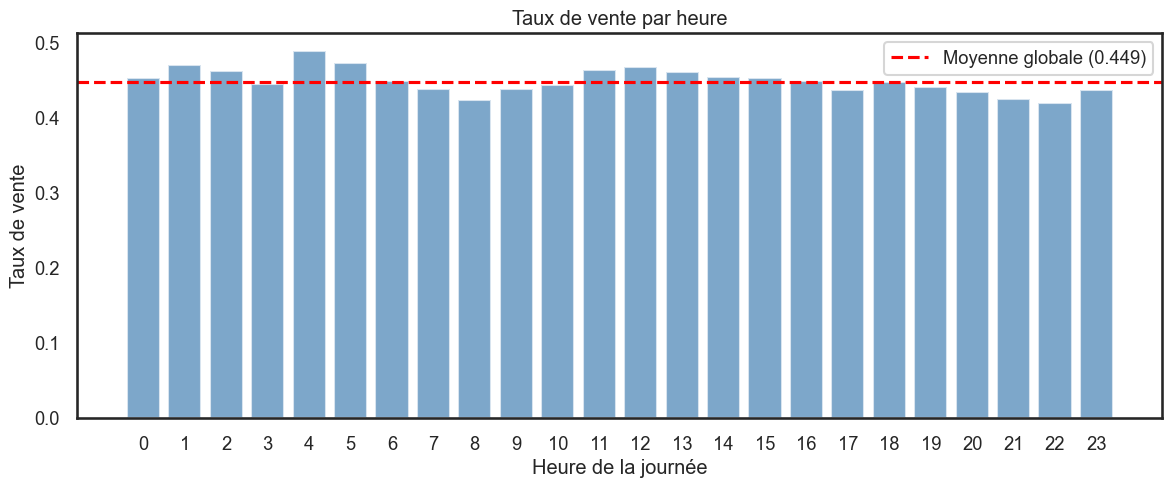

In [57]:
plt.figure(figsize=(14, 5))
plt.bar(hour_stats['hour'], hour_stats['mean'], color='steelblue', alpha=0.7)
plt.axhline(global_mean, color='red', linestyle='--', label=f'Moyenne globale ({global_mean:.3f})')
plt.xlabel('Heure de la journée')
plt.ylabel('Taux de vente')
plt.title('Taux de vente par heure')
plt.xticks(range(0, 24))
plt.legend()
plt.show()

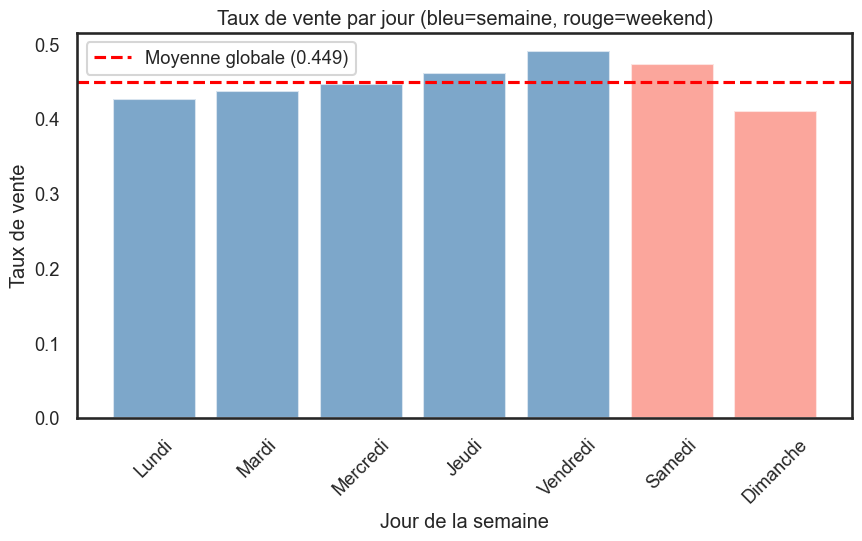

In [59]:
colors = ['salmon' if i >= 5 else 'steelblue' for i in day_stats['dayofweek']]
plt.figure(figsize=(10, 5))
plt.bar(day_stats['dayofweek'], day_stats['mean'], color=colors, alpha=0.7)
plt.axhline(global_mean, color='red', linestyle='--', label=f'Moyenne globale ({global_mean:.3f})')
plt.xlabel('Jour de la semaine')
plt.ylabel('Taux de vente')
plt.title('Taux de vente par jour (bleu=semaine, rouge=weekend)')
plt.xticks(range(7), day_labels, rotation=45)
plt.legend()
plt.show()

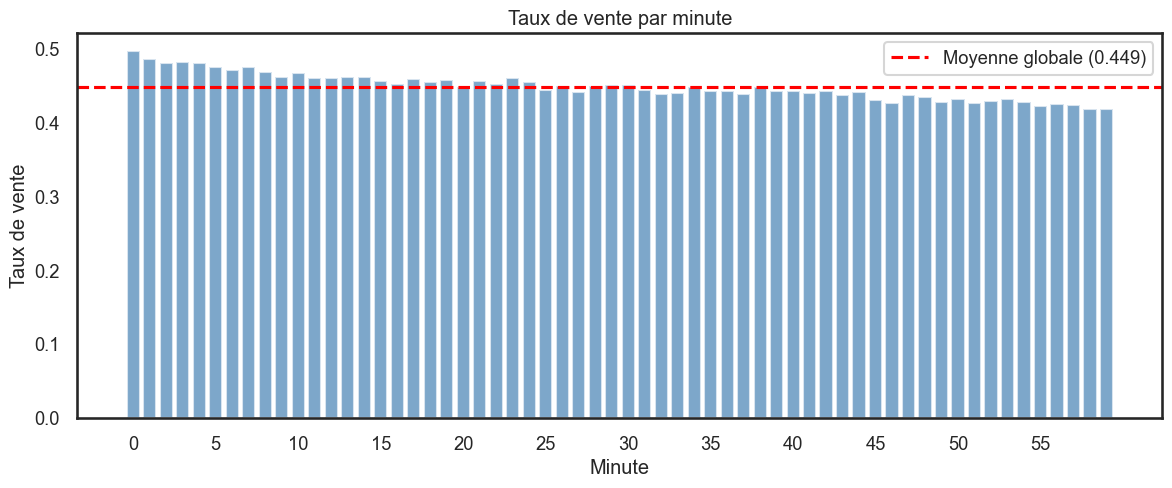

In [60]:
df_eda['minute'] = dt.dt.minute
minute_stats = df_eda.groupby('minute')['isSold'].agg(['mean', 'count']).reset_index()

plt.figure(figsize=(14, 5))
plt.bar(minute_stats['minute'], minute_stats['mean'], color='steelblue', alpha=0.7)
plt.axhline(global_mean, color='red', linestyle='--', label=f'Moyenne globale ({global_mean:.3f})')
plt.xlabel('Minute')
plt.ylabel('Taux de vente')
plt.title('Taux de vente par minute')
plt.xticks(range(0, 60, 5))
plt.legend()
plt.show()

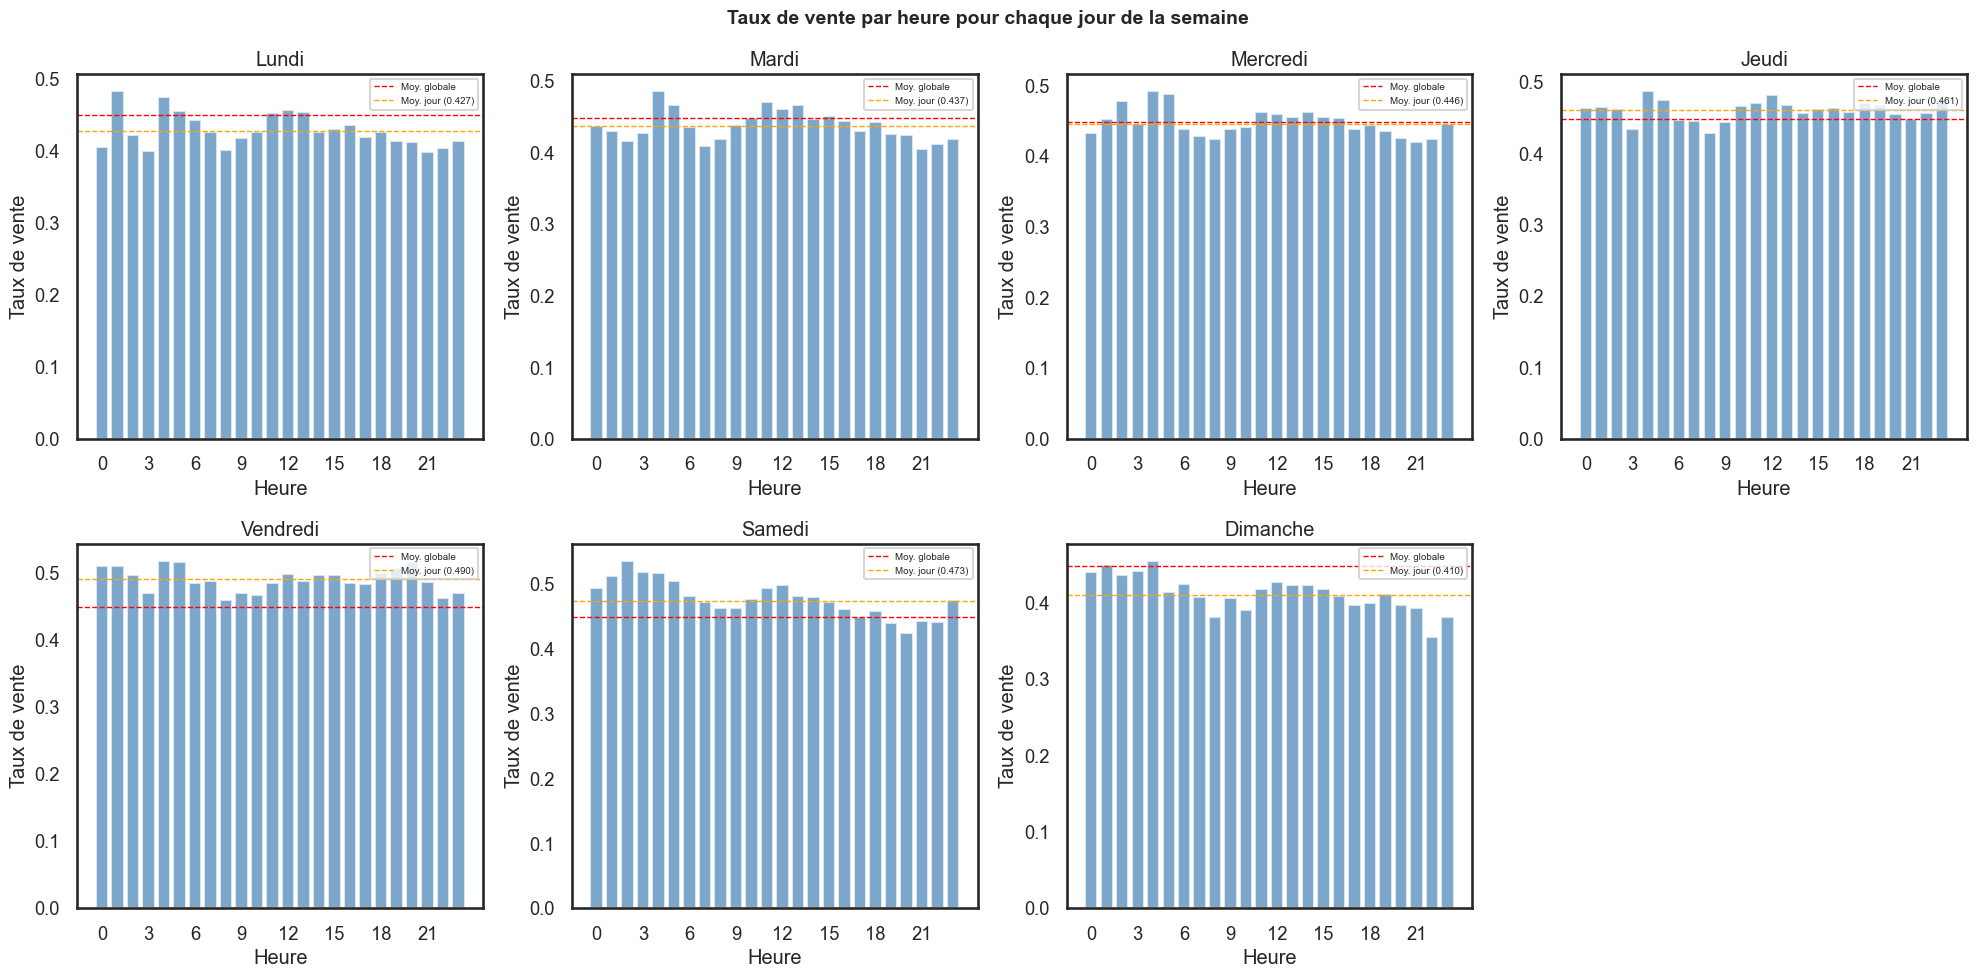

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, day in enumerate(day_labels):
    df_day = df_eda[df_eda['dayofweek'] == i]
    hour_day_stats = df_day.groupby('hour')['isSold'].mean().reset_index()
    
    axes[i].bar(hour_day_stats['hour'], hour_day_stats['isSold'], color='steelblue', alpha=0.7)
    axes[i].axhline(global_mean, color='red', linestyle='--', linewidth=1, label=f'Moy. globale')
    axes[i].axhline(df_day['isSold'].mean(), color='orange', linestyle='--', linewidth=1, label=f'Moy. jour ({df_day["isSold"].mean():.3f})')
    axes[i].set_title(day)
    axes[i].set_xlabel('Heure')
    axes[i].set_ylabel('Taux de vente')
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)  # 8ème case vide (2x4 = 8 cases, 7 jours)

plt.suptitle('Taux de vente par heure pour chaque jour de la semaine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Partie Modèles

In [26]:
from sklearn.preprocessing import StandardScaler
def Normalize(X):
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    return X

In [32]:
from sklearn.model_selection import train_test_split

X = preprocess_data(df.copy())

y = df['isSold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

training_columns = X_train.columns.tolist()

Partie random forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [29]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score

y_pred = rf.predict(X_test)
print('accuracy: ', accuracy_score(y_test, y_pred))
print('precision score: ', precision_score(y_test, y_pred))
print('f1 score: ', f1_score(y_test, y_pred))
print('recall score: ', recall_score(y_test, y_pred))

accuracy:  0.7411134715481194
precision score:  0.7261302814295932
f1 score:  0.7015919544338791
recall score:  0.6786578759307499


In [50]:
#Final df is the test set with the auction ids and the predicted isSold values.
final_df = pd.read_csv('test.csv')
final_df.head()

,auctionId,timeStamp,placementId,websiteId,hashedRefererDeepThree,country,opeartingSystem,browser,browserVersion,device,environmentType,integrationType,articleSafenessCategorization
0,00277acc-dee5-4065-a580-c49dbde5c02e_6c6fd7b0-...,1604180182,120706,68203,8448d2635d8ce25f3758907451fc740c4b2131693c7a8b...,CA,iOS,Facebook App,NaN,Phone,js-web,2,safe
1,0055d24f-bbf0-418d-84e7-df1d3124d6d6_60eaa750-...,1604145756,120706,68203,513dc346ab569ee76d6dbc927079b4049b1e9e95833d13...,US,Android,Facebook App,293_0,Phone,js-web,2,safe
2,005bc881-b650-4ccc-baa6-850c9710b0ea_15181501-...,1604095938,120706,68203,7b856dd2cffe043b51f48f9094a6a8bc58dbdea3bdd239...,MX,Android,Facebook App,274_0,Phone,js-web,2,safe
3,008c5f32-c29f-4726-8315-a2a4f2d10fb2_a4a0167f-...,1604257787,120706,68203,8448d2635d8ce25f3758907451fc740c4b2131693c7a8b...,US,iOS,Safari mobile,13_1,Phone,js-web,2,safe
4,00f96be1-59f2-43b6-a6d1-0668001cd08c_1014d516-...,1604265857,120706,68203,a64b4cf5e410623d0bb3d110b2d3183c1590f69e0e61af...,CA,Windows,Microsoft Edge,86_0,PC,js-web,2,unsafe


In [51]:
X = preprocess_data(final_df.copy())
X = X.reindex(columns=training_columns, fill_value=0)

y_pred_final = rf.predict(X)

In [53]:
submission_df = pd.DataFrame({'auctionId': final_df['auctionId'], 'isSold': y_pred_final})
submission_df.head()
submission_df.to_csv('BaselineSubmissionFile.csv', index=False)

Partie Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [31]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score

y_pred = lr.predict(X_test)
print('accuracy: ', accuracy_score(y_test, y_pred))
print('precision score: ', precision_score(y_test, y_pred))
print('f1 score: ', f1_score(y_test, y_pred))
print('recall score: ', recall_score(y_test, y_pred))

accuracy:  0.6786170251257321
precision score:  0.6486855953835545
f1 score:  0.6329986601266682
recall score:  0.618052513889209


Partie Lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(300, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'num_leaves': randint(31, 255),
    'max_depth': randint(5, 15),
    'min_child_samples': randint(20, 200),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

lgbm_base = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_dist,
    n_iter=30,          # 30 combinaisons aléatoires
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV f1:', search.best_score_)

y_pred = search.best_estimator_.predict(X_test)
print('Test f1:', f1_score(y_test, y_pred))

In [ ]:
param_dist = {
    'n_estimators': randint(300, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'num_leaves': randint(31, 255),
    'max_depth': randint(5, 15),
    'min_child_samples': randint(20, 200),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

lgbm_base = lgb.LGBMClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_dist,
    n_iter=30,          # 30 combinaisons aléatoires
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV f1:', search.best_score_)

y_pred = search.best_estimator_.predict(X_test)
print('Test f1:', f1_score(y_test, y_pred))

In [37]:
import joblib

# Sauvegarder le meilleur modèle
joblib.dump(search.best_estimator_, 'lgbm_best_model.pkl')

['lgbm_best_model.pkl']

In [41]:
import json

# Sauvegarder
with open('best_params.json', 'w') as f:
    json.dump(search.best_params_, f)

# Recharger plus tard
with open('best_params.json', 'r') as f:
    best_params = json.load(f)

In [51]:
# Data preprocessing
def preprocess_data_2(X):
    X.rename(columns={'opeartingSystem': 'operatingSystem'}, inplace=True)
    class_dummies = pd.get_dummies(X['country'], prefix = 'country')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['operatingSystem'], prefix = 'operatingSystem')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['browser'], prefix = 'browser')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['device'], prefix = 'device')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['environmentType'], prefix = 'environmentType')
    X = X.join(class_dummies)
    class_dummies = pd.get_dummies(X['articleSafenessCategorization'], prefix = 'articleSafenessCategorization')
    X = X.join(class_dummies)
    
    ### Difference par rapport à avant (+ on drop le timestamp)
    dt = pd.to_datetime(X['timeStamp'], unit='s')
    X['hour'] = dt.dt.hour
    X['minute'] = dt.dt.minute
    X['dayofweek'] = dt.dt.dayofweek
    X['is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    ### 
    
    X = X.drop(columns=['country', 'operatingSystem', 'browser', 'device', 'environmentType', 'articleSafenessCategorization', 'hashedRefererDeepThree', 'browserVersion','timeStamp'])
    if 'isSold' in X.columns:
        X = X.drop(columns=['isSold'])
    return X

In [53]:
from sklearn.model_selection import train_test_split

X = preprocess_data_2(df.copy())

y = df['isSold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

training_columns = X_train.columns.tolist()

In [54]:
with open('best_params.json', 'r') as f:
    best_params = json.load(f)

lgbm_v2 = lgb.LGBMClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgbm_v2.fit(X_train, y_train)
y_pred = lgbm_v2.predict(X_test)
print('f1 score: ', f1_score(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 347149, number of negative: 426716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1036
[LightGBM] [Info] Number of data points in the train set: 773865, number of used features: 222
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

Submission

In [49]:
model = lgbm_v2

final_df = pd.read_csv('test.csv')
final_df.head()

X = preprocess_data_2(final_df.copy())
X = X.reindex(columns=training_columns, fill_value=0)
y_pred_final = model.predict(X)

In [50]:
submission_df = pd.DataFrame({'auctionId': final_df['auctionId'], 'isSold': y_pred_final})
submission_df.head()
submission_df.to_csv('SubmissionFileLightGBM_v2.csv', index=False)